In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as pp
import sklearn.metrics as ms
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from warnings import filterwarnings
filterwarnings('ignore')

In [256]:
df=pd.read_csv(r"C:\Users\Lenovo\Desktop\Datas\Python\HR_comma_sep.csv")
df.head(20)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [257]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

<Axes: xlabel='left', ylabel='last_evaluation'>

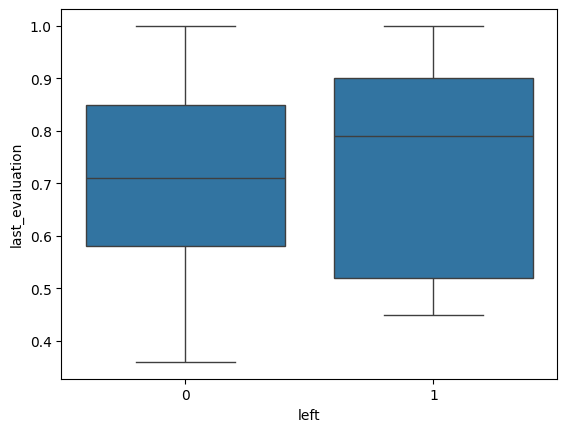

In [258]:
sns.boxplot(x='left',y='last_evaluation',data=df)

The boxplot shows that employees who leave the company tend to have slightly higher last evaluation scores compared to those who stay. This suggests that high-performing employees may still leave the organization, possibly due to higher workload, lack of promotion opportunities, or better external job offers. Therefore, performance alone does not guarantee employee retention.


<Axes: xlabel='left', ylabel='time_spend_company'>

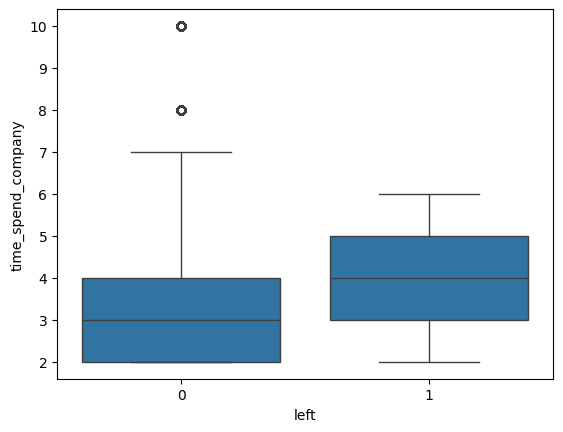

In [259]:
sns.boxplot(x='left',y='time_spend_company',data=df)

The boxplot shows a slight difference in the time employees spend at the company between those who leave and those who stay. Employees who remain in the company generally have around 2 to 4 years of tenure, while employees who leave tend to have slightly higher tenure, typically between 3 and 5 years. Although the distributions overlap, the results suggest that employees with around 3 to 5 years at the company may be more likely to leave.


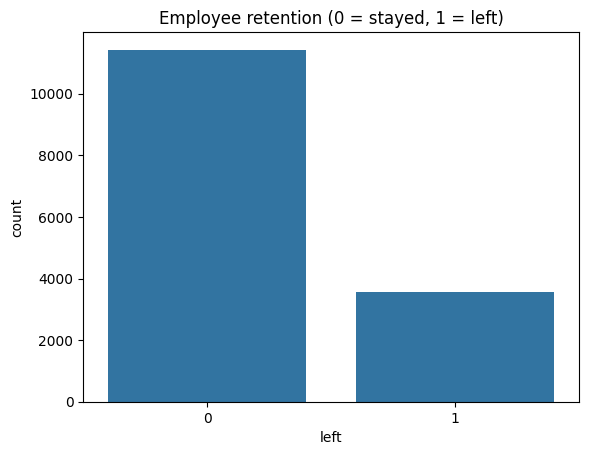

In [260]:
sns.countplot(x='left',data=df)
plt.title("Employee retention (0 = stayed, 1 = left)")
plt.show()

<Axes: xlabel='left', ylabel='satisfaction_level'>

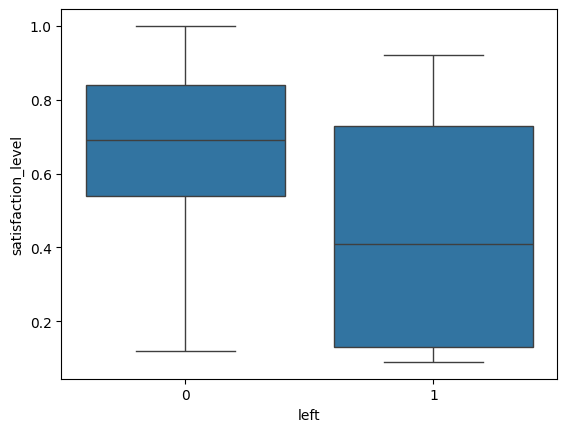

In [261]:
sns.boxplot(x='left',y='satisfaction_level',data=df)

<Axes: xlabel='left', ylabel='number_project'>

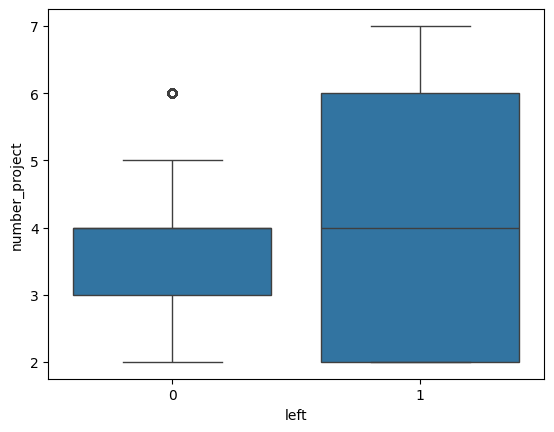

In [262]:
sns.boxplot(x='left',y='number_project',data=df)

The boxplot indicates that the number of projects has a noticeable relationship with employee retention. Employees who remain in the company typically work on around 3 to 4 projects. However, employees who leave the company show a wider distribution of project counts, including both very low and very high numbers of projects. This suggests that both underutilization and excessive workload may contribute to employee turnover.


<Axes: xlabel='left', ylabel='average_montly_hours'>

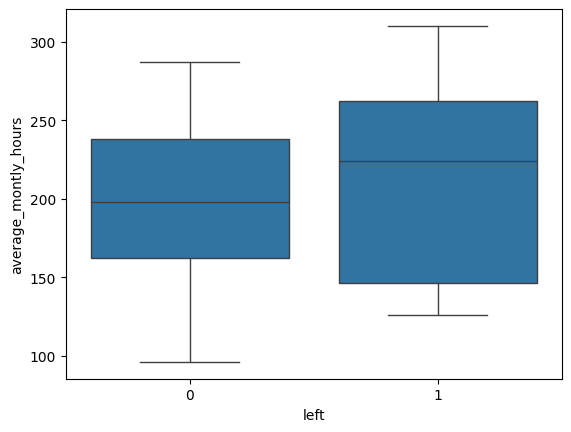

In [263]:
sns.boxplot(x='left',y='average_montly_hours',data=df)

In [264]:
bins=[90,150,220,260,330]
labels=["low","Normal","High","Overworked"]
df['workload']=pd.cut(df['average_montly_hours'],bins=bins,labels=labels)
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,workload
0,0.38,0.53,2,157,3,0,1,0,sales,low,Normal
1,0.80,0.86,5,262,6,0,1,0,sales,medium,Overworked
2,0.11,0.88,7,272,4,0,1,0,sales,medium,Overworked
3,0.72,0.87,5,223,5,0,1,0,sales,low,High
4,0.37,0.52,2,159,3,0,1,0,sales,low,Normal
...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low,Normal
14995,0.37,0.48,2,160,3,0,1,0,support,low,Normal
14996,0.37,0.53,2,143,3,0,1,0,support,low,low
14997,0.11,0.96,6,280,4,0,1,0,support,low,Overworked


,workload,left
3,Overworked,43.05
0,low,35.57
2,High,23.80
1,Normal,10.90


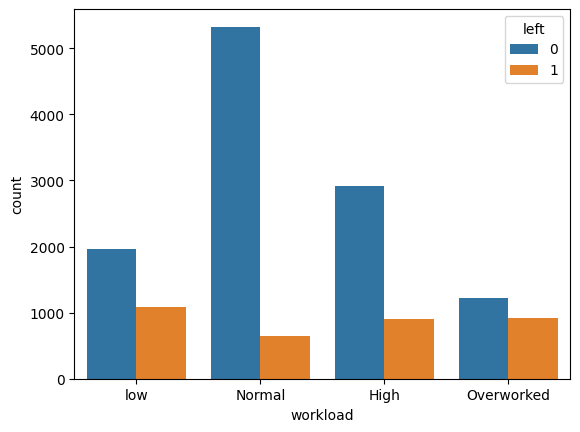

In [265]:
sns.countplot(x='workload',hue='left',data=df)
workload_left_rate=df.groupby('workload')['left'].mean()*100
workload_left_rate_df=workload_left_rate.reset_index().sort_values(by='left',ascending=False)
workload_left_rate_df

KEY FINDINGS FOR RECRUITERS

1. THE "BURNOUT" ZONE (Overworked - 43% Exit Rate):
mployees working extreme hours are leaving due to stress and exhaustion. 
 This is the highest risk group.

2. THE "BOREDOM" ZONE (Low Workload - 35.6% Exit Rate):
Surprisingly, employees with too little work are also leaving. 
They likely feel undervalued, bored, or fear their skills are stagnating.

3. THE "SWEET SPOT" (Normal - 10.9% Exit Rate):
A balanced workload is our best retention tool. Employees in this range 
are nearly 4x more likely to stay than those who are overworked.

TAKEAWAY: To keep talent, we must balance the load. 
We need to reduce pressure on the overworked and give more 
challenging tasks to those with low workloads.

In [266]:
churn_rates=df.groupby('Department')['left'].mean()*100
churn_rates_df = churn_rates.reset_index().sort_values(by='left', ascending=False)
churn_rates_df

,Department,left
3,hr,29.09
2,accounting,26.60
9,technical,25.62
8,support,24.90
7,sales,24.49
5,marketing,23.66
0,IT,22.25
6,product_mng,21.95
1,RandD,15.37
4,management,14.44


In [267]:
df=pd.get_dummies(df,columns=['salary','workload','Department'],dtype=int,drop_first=True)
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_low,salary_medium,workload_Normal,workload_High,workload_Overworked,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0


In [268]:
X_train,X_test,Y_train,Y_test=train_test_split(df.drop(columns=['left']),df[['left']],test_size=0.20,random_state=25)

 ANALYSIS & KEY INSIGHTS 

1. High Turnover Risk (HR & Accounting): 
 Despite lower absolute numbers, HR (29%) and Accounting (~26%) have the highest 
 churn rates. Nearly 1 in 3 employees in HR leave the company. This is a critical area.

2. Volume vs. Percentage (Sales): 
 Sales has the highest number of departures, but its churn rate (24.5%) 
 is actually moderate due to the large size of the department.

3. Most Stable Departments (Management & RandD): 
Management has the lowest churn rate (14.4%), followed by RandD (15.4%). 
These areas show the highest employee retention and job satisfaction.

4. Conclusion: 
Raw counts (bar heights) can be misleading. Focusing on percentages reveals 
that small departments like HR require more urgent retention strategies.

In [269]:
X_train.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'salary_low', 'salary_medium',
       'workload_Normal', 'workload_High', 'workload_Overworked',
       'Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'],
      dtype='object')

In [270]:
colms_to_scl=['satisfaction_level', 'last_evaluation', 'number_project','average_montly_hours','time_spend_company']

In [271]:
ss=pp.RobustScaler()
X_train[colms_to_scl]=ss.fit_transform(X_train[colms_to_scl])
X_test[colms_to_scl]=ss.fit_transform(X_test[colms_to_scl])


In [272]:
X_train

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_low,salary_medium,workload_Normal,workload_High,workload_Overworked,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
13841,0.08,-0.16,0.00,-0.43,7.00,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
14359,0.50,0.52,0.00,0.71,2.00,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0
12215,-0.76,-0.68,-1.00,-0.51,0.00,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
1383,-0.58,-0.84,-1.00,-0.62,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
7376,-1.08,-1.10,1.00,-1.02,-1.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934,0.32,0.10,0.00,0.28,0.00,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
10383,0.74,0.29,-0.50,-0.64,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
6618,0.61,-0.23,-0.50,0.76,-1.00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
8510,0.18,0.74,0.00,0.34,0.00,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1


**Modelling**

In [273]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [274]:
# to merge all scores and metrics results altogether
performance=pd.DataFrame(data=None, index=['BAS','AS'])
performance

""
BAS
AS


In [275]:
# creating function to evaluate model at one run
def evaluate(model,model_name):
    performance[model_name]=[ms.balanced_accuracy_score(Y_test,model.predict(X_test)),
                             ms.accuracy_score(Y_test,model.predict(X_test))]
    
    print(ms.classification_report(Y_test,model.predict(X_test)))
    print("-------Balance Accuracy Score------")
    print(ms.balanced_accuracy_score(Y_test,model.predict(X_test)))
    print("------Accuracy Score-----")
    print(ms.accuracy_score(Y_test,model.predict(X_test)))

pd.options.display.float_format = '{:.2f}'.format


In [276]:
from sklearn.model_selection import GridSearchCV

**Logistic regression**

In [277]:
parameters = {'penalty':('l1','l2','elastic','none'),'C':[1,10,50,100]}
lr1=LogisticRegression()
clf1=GridSearchCV(lr1,parameters)
clf1.fit(X_train,Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'penalty': ('l1', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [278]:
GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C':[1,10,50,100],
            'penalty':('l1','l2','elastic','none')})

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'penalty': ('l1', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [279]:
evaluate(clf1,'Log_Reg_0.5')

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      2265
           1       0.68      0.43      0.53       735

    accuracy                           0.81      3000
   macro avg       0.76      0.68      0.70      3000
weighted avg       0.80      0.81      0.79      3000

-------Balance Accuracy Score------
0.68161463260801
------Accuracy Score-----
0.8106666666666666


In [280]:
## probabilties of observations
pd.DataFrame(clf1.predict_proba(X_test)).head()

,0,1
0,0.99,0.01
1,0.93,0.07
2,0.96,0.04
3,0.95,0.05
4,0.57,0.43


In [281]:
# defining cutoff point
cutoff = Y_train.left.mean()
cutoff

np.float64(0.23635302941911826)

In [282]:
prd=(pd.DataFrame(clf1.predict_proba(X_test))[1]>cutoff).astype(np.int8)
prd

0       0
1       0
2       0
3       0
4       1
       ..
2995    1
2996    0
2997    0
2998    0
2999    0
Name: 1, Length: 3000, dtype: int8

In [283]:
print(ms.classification_report(Y_test,prd))
print("-----Balanced Accuracy Score------")
print(ms.balanced_accuracy_score(Y_test,prd))
print("------Accuracy Score-------")
print(ms.accuracy_score(Y_test,prd))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2265
           1       0.51      0.76      0.61       735

    accuracy                           0.76      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.76      0.78      3000

-----Balanced Accuracy Score------
0.7596702257061765
------Accuracy Score-------
0.762


In [284]:
performance['Log_reg_23']=[ms.balanced_accuracy_score(Y_test,prd),
            ms.accuracy_score(Y_test,prd)]
performance

,Log_Reg_0.5,Log_reg_23
BAS,0.68,0.76
AS,0.81,0.76


RandomForest classification model

In [285]:
import sklearn.ensemble as sen


In [286]:
parameters = { 'n_estimators':[i for i in range(150,200,10)] }
rfc = sen.RandomForestClassifier(random_state=25)
clf2=GridSearchCV(rfc,parameters)
clf2.fit(X_train,Y_train)
clf2.best_params_



{'n_estimators': 160}

In [287]:
evaluate(clf2,"R_Forest_0.5")

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2265
           1       0.99      0.85      0.91       735

    accuracy                           0.96      3000
   macro avg       0.97      0.92      0.94      3000
weighted avg       0.96      0.96      0.96      3000

-------Balance Accuracy Score------
0.9220254989412984
------Accuracy Score-----
0.9606666666666667


In [288]:
performance

,Log_Reg_0.5,Log_reg_23,R_Forest_0.5
BAS,0.68,0.76,0.92
AS,0.81,0.76,0.96


In [289]:
prd=(pd.DataFrame(clf2.predict_proba(X_test))[1]>cutoff).astype(np.int8)
prd

0       0
1       0
2       0
3       0
4       1
       ..
2995    0
2996    0
2997    0
2998    0
2999    0
Name: 1, Length: 3000, dtype: int8

In [290]:
print(ms.classification_report(Y_test,prd))
print("--------Balanced Accuracy Score-------")
print(ms.balanced_accuracy_score(Y_test,prd))
print("-----------Accuracy Score------------")
print(ms.accuracy_score(Y_test,prd))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2265
           1       0.97      0.95      0.96       735

    accuracy                           0.98      3000
   macro avg       0.98      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000

--------Balanced Accuracy Score-------
0.9686128756138217
-----------Accuracy Score------------
0.9796666666666667


In [291]:
performance['R_Forest_0.23']=[ms.balanced_accuracy_score(Y_test,prd),
            ms.accuracy_score(Y_test,prd)]
performance

,Log_Reg_0.5,Log_reg_23,R_Forest_0.5,R_Forest_0.23
BAS,0.68,0.76,0.92,0.97
AS,0.81,0.76,0.96,0.98


The final tuned model (R_Forest_0.23) achieved an outstanding 97% Balanced Accuracy and 98% Overall Accuracy, demonstrating its exceptional ability to generalize and make precise predictions. This approach proves that tailoring the decision threshold to the specific distribution of the dataset is a critical step in building high-performance machine learning pipelines